# First training pass on the final linearized dataset

This notebook trains a first model on `linearized_session_windows_30min.csv`.

For this training pass, temperature, humidity, light, noise, and CO2 features are used because the final linearized dataset now contains all five sensor families without missing values.

The target `focus_score` is a pseudo-rating, not verified ground truth.

This is an initial experiment, not the final evaluation setup. It builds on top of `quick_demo`, where we showed that a model can be trained on the final linearized dataset and can produce basic predictions from the features. The final linearized CSV does not contain session metadata anymore, so the split below is random and may contain overlap between similar rolling windows.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
)
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../../data/processed/linearized_session_windows_30min.csv")

TARGET_COLUMN = "focus_score"
RANDOM_STATE = 42

df.head()

,focus_score,temperature_latest,temperature_mean,temperature_min,temperature_max,temperature_std,temperature_count,temperature_range,humidity_latest,humidity_mean,...,noise_std,noise_count,noise_range,co2_latest,co2_mean,co2_min,co2_max,co2_std,co2_count,co2_range
0,2,17.7,17.700000,17.7,17.7,0.000000,1,0.0,3136.0,3136.000000,...,0.000000,1,0.000000,0.000434,0.000434,0.000434,0.000434,0.000000,1,0.000000
1,2,17.9,17.800000,17.7,17.9,0.141421,2,0.2,3136.0,3136.000000,...,0.253605,2,0.358651,0.000444,0.000439,0.000434,0.000444,0.000007,2,0.000011
2,3,18.3,17.966667,17.7,18.3,0.305505,3,0.6,3249.0,3173.666667,...,0.297101,3,0.589612,0.000437,0.000439,0.000434,0.000444,0.000005,3,0.000011
3,3,18.9,18.200000,17.7,18.9,0.529150,4,1.2,3249.0,3192.500000,...,0.504923,4,1.159191,0.000441,0.000439,0.000434,0.000444,0.000005,4,0.000011
4,5,19.1,18.380000,17.7,19.1,0.609918,5,1.4,3249.0,3203.800000,...,0.603961,5,1.426495,0.000447,0.000441,0.000434,0.000447,0.000005,5,0.000013


In [3]:
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="rows")
)

target_distribution["percent"] = (
    target_distribution["rows"] / len(df) * 100
).round(2)

target_distribution

Rows: 947,898
Columns: 36


,focus_score,rows,percent
0,1,13312,1.40
1,2,110177,11.62
2,3,450218,47.50
3,4,248581,26.22
4,5,125610,13.25


## Select features

For this model, temperature, humidity, light, noise, and CO2 are used because the final linearized dataset now contains all five sensor families without missing values.

The `*_count` columns are still left out because they describe the sampling pattern and may reveal the source dataset instead of only describing the environmental condition.

In [4]:
base_features = ["temperature", "humidity", "light", "noise", "co2"]
window_stats = ["latest", "mean", "min", "max", "std", "range"]

feature_columns = [
    f"{feature}_{stat}"
    for feature in base_features
    for stat in window_stats
]

model_df = df[[TARGET_COLUMN, *feature_columns]].dropna().copy()

print(f"Rows before filtering: {len(df):,}")
print(f"Rows after filtering:  {len(model_df):,}")
print(f"Rows removed:          {len(df) - len(model_df):,}")

print("\nMissing values left in model data:")
print(model_df.isna().sum().sum())

model_df.head()

Rows before filtering: 947,898
Rows after filtering:  947,898
Rows removed:          0

Missing values left in model data:
0


,focus_score,temperature_latest,temperature_mean,temperature_min,temperature_max,temperature_std,temperature_range,humidity_latest,humidity_mean,humidity_min,...,noise_min,noise_max,noise_std,noise_range,co2_latest,co2_mean,co2_min,co2_max,co2_std,co2_range
0,2,17.7,17.700000,17.7,17.7,0.000000,0.0,3136.0,3136.000000,3136.0,...,8.185353,8.185353,0.000000,0.000000,0.000434,0.000434,0.000434,0.000434,0.000000,0.000000
1,2,17.9,17.800000,17.7,17.9,0.141421,0.2,3136.0,3136.000000,3136.0,...,8.185353,8.544004,0.253605,0.358651,0.000444,0.000439,0.000434,0.000444,0.000007,0.000011
2,3,18.3,17.966667,17.7,18.3,0.305505,0.6,3249.0,3173.666667,3136.0,...,8.185353,8.774964,0.297101,0.589612,0.000437,0.000439,0.000434,0.000444,0.000005,0.000011
3,3,18.9,18.200000,17.7,18.9,0.529150,1.2,3249.0,3192.500000,3136.0,...,7.615773,8.774964,0.504923,1.159191,0.000441,0.000439,0.000434,0.000444,0.000005,0.000011
4,5,19.1,18.380000,17.7,19.1,0.609918,1.4,3249.0,3203.800000,3136.0,...,7.348469,8.774964,0.603961,1.426495,0.000447,0.000441,0.000434,0.000447,0.000005,0.000013


## Rating distribution before and after filtering

Rows with missing values in the selected training features would be removed here. After fixing the light and noise merge problem, no rows are removed in this version of the final linearized dataset.

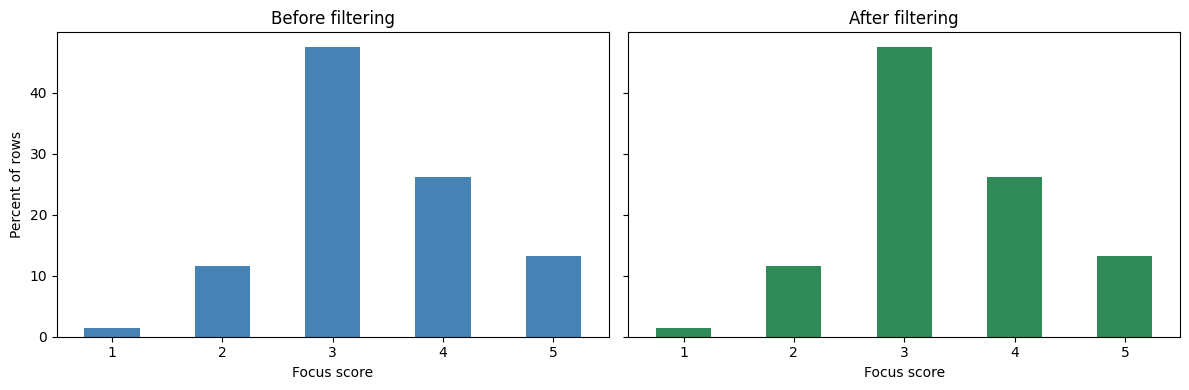

In [5]:
target_distribution = (
    df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="rows")
)

target_distribution["percent"] = (
    target_distribution["rows"] / len(df) * 100
).round(2)

filtered_target_distribution = (
    model_df[TARGET_COLUMN]
    .value_counts()
    .sort_index()
    .rename_axis(TARGET_COLUMN)
    .reset_index(name="rows")
)

filtered_target_distribution["percent"] = (
    filtered_target_distribution["rows"] / len(model_df) * 100
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

target_distribution.plot(
    x=TARGET_COLUMN,
    y="percent",
    kind="bar",
    legend=False,
    color="steelblue",
    ax=axes[0],
)
axes[0].set_title("Before filtering")
axes[0].set_xlabel("Focus score")
axes[0].set_ylabel("Percent of rows")
axes[0].tick_params(axis="x", rotation=0)

filtered_target_distribution.plot(
    x=TARGET_COLUMN,
    y="percent",
    kind="bar",
    legend=False,
    color="seagreen",
    ax=axes[1],
)
axes[1].set_title("After filtering")
axes[1].set_xlabel("Focus score")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## Train-validation split

A stratified random split is used in this first experiment so that every rating class stays represented in both sets.

For the final evaluation, this should later be replaced with a session-based or location-based split to reduce leakage between overlapping rolling windows.

In [6]:
X = model_df[feature_columns]
y = model_df[TARGET_COLUMN].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Training rows:   {len(X_train):,}")
print(f"Validation rows: {len(X_val):,}")

Training rows:   758,318
Validation rows: 189,580


## Evaluation metrics

Because the classes are imbalanced, accuracy alone is not enough.  
The models are compared using accuracy, balanced accuracy, macro F1, mean absolute error, and the share of predictions that are within one rating point of the true value.

In [7]:
def evaluate_predictions(y_true, predictions):
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "macro_f1": f1_score(y_true, predictions, average="macro"),
        "mae": mean_absolute_error(y_true, predictions),
        "within_1_rating": (abs(predictions - y_true) <= 1).mean(),
    }

## Model choice

The previous experiment notebooks compared several different approaches before the final linearized dataset was ready.

The **linear regression** experiments were useful for understanding feature importance, but they also showed that treating the rating as a continuous value is not a very natural fit, because the target is a discrete score from 1 to 5.

**Logistic regression** was tested as a simpler classification model. It performed better than the baseline, but it was still weaker than the more flexible nonlinear models.

The **neural network** experiments showed that a neural network can work on this task, but the dataset is imbalanced and the model is harder to explain and maintain. Because of that, it was not the most suitable first choice for the project.

The **random forest** experiments gave the best overall balance so far. Random forest handled nonlinear relationships better than the linear models, performed well compared with the neural network experiments, and also provided feature importance values that are useful for interpretation.

For this first training pass on the final linearized dataset, a __Random Forest__ classifier is therefore used as the main model. This continues the direction already established in the earlier project experiments.

## Baseline model

Before evaluating the Random Forest, a simple baseline model is created.

This baseline always predicts the most common rating. Because rating 3 is the largest class, the Random Forest should perform better than this baseline to be useful.

In [8]:
baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_val)

baseline_metrics = evaluate_predictions(y_val, baseline_predictions)

pd.DataFrame([baseline_metrics], index=["Dummy baseline"]).round(3)

,accuracy,balanced_accuracy,macro_f1,mae,within_1_rating
Dummy baseline,0.475,0.2,0.129,0.672,0.853


## Random Forest model

A Random Forest classifier is used as the first main model on the final linearized dataset.

`class_weight="balanced"` is used because the rating classes are imbalanced, so the model gives more attention to the rare classes instead of mainly learning the most common rating.

In [9]:
random_forest_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

random_forest_model.fit(X_train, y_train)

random_forest_predictions = random_forest_model.predict(X_val)
random_forest_metrics = evaluate_predictions(y_val, random_forest_predictions)

pd.DataFrame([random_forest_metrics], index=["Random Forest"]).round(3)

,accuracy,balanced_accuracy,macro_f1,mae,within_1_rating
Random Forest,0.475,0.2,0.129,0.672,0.853


## Random Forest with balanced class weights

The rating classes are imbalanced. Rating 3 is much more common than rating 1, so a normal model can get a fairly high accuracy while still doing poorly on the rare ratings.

A second Random Forest is therefore trained with `class_weight="balanced"`. This gives more importance to the rare classes during training and less importance to the classes that appear very often.

The goal is not necessarily to improve normal accuracy. Instead, the balanced model is tested to see whether it improves metrics that treat every class more equally, especially balanced accuracy and macro F1.

In [10]:
balanced_random_forest_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

balanced_random_forest_model.fit(X_train, y_train)

balanced_random_forest_predictions = balanced_random_forest_model.predict(X_val)
balanced_random_forest_metrics = evaluate_predictions(
    y_val,
    balanced_random_forest_predictions,
)

pd.DataFrame(
    [balanced_random_forest_metrics],
    index=["Balanced Random Forest"],
).round(3)

,accuracy,balanced_accuracy,macro_f1,mae,within_1_rating
Balanced Random Forest,0.301,0.248,0.194,1.109,0.7


## Model comparison

In [11]:
results = pd.DataFrame(
    [
        baseline_metrics,
        random_forest_metrics,
        balanced_random_forest_metrics,
    ],
    index=[
        "Dummy baseline",
        "Random Forest",
        "Balanced Random Forest",
    ],
)

results.round(3)

,accuracy,balanced_accuracy,macro_f1,mae,within_1_rating
Dummy baseline,0.475,0.200,0.129,0.672,0.853
Random Forest,0.475,0.200,0.129,0.672,0.853
Balanced Random Forest,0.301,0.248,0.194,1.109,0.700


In [12]:
prediction_distribution = pd.DataFrame(
    {
        "Dummy baseline": pd.Series(baseline_predictions).value_counts().sort_index(),
        "Random Forest": pd.Series(random_forest_predictions).value_counts().sort_index(),
        "Balanced Random Forest": pd.Series(balanced_random_forest_predictions).value_counts().sort_index(),
    }
).fillna(0).astype(int)

prediction_distribution

,Dummy baseline,Random Forest,Balanced Random Forest
1,0,0,34142
2,0,0,11468
3,189580,189554,77072
4,0,25,55128
5,0,1,11770


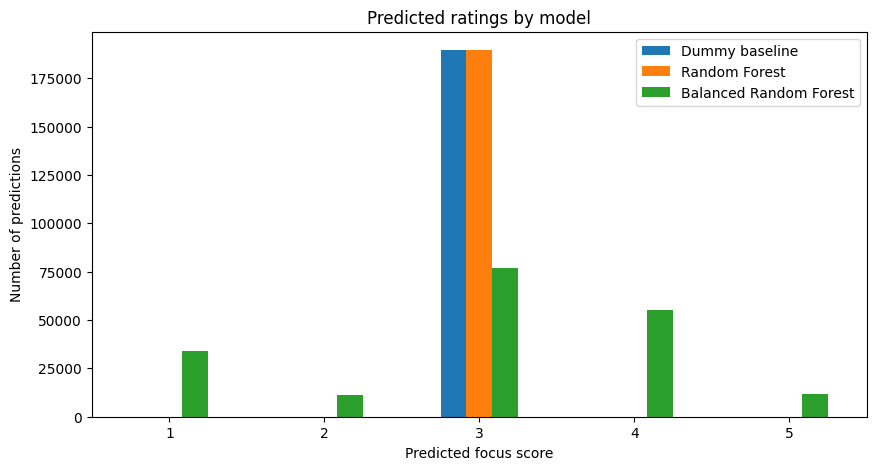

In [13]:
prediction_distribution.plot(
    kind="bar",
    figsize=(10, 5),
)

plt.title("Predicted ratings by model")
plt.xlabel("Predicted focus score")
plt.ylabel("Number of predictions")
plt.xticks(rotation=0)
plt.show()